# 02 Stage 1 Logistic Regression

Train and evaluate Logistic Regression for all three Stage 1 barrier targets on the individual-level dataset (N=724,115). Uses `class_weight='balanced'`; SMOTE is optional via `split_and_scale(use_smote=True)`.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.split_scale import split_and_scale
from src.models.logistic_regression import train_logistic

print('Project root:', PROJECT_ROOT)

Project root: b:\PBCS\Major Project\BarrierLens_MP_G25_P48


In [2]:
X = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_features.csv')
y_household = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_household.csv').squeeze('columns')
y_logistic = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_logistic.csv').squeeze('columns')
y_facility = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_facility.csv').squeeze('columns')

print('X shape:', X.shape)
print('Household distribution:', y_household.value_counts().to_dict())

X shape: (724115, 37)
Household distribution: {0: 527477, 1: 196638}


In [3]:
from sklearn.model_selection import train_test_split

CV_SAMPLE_SIZE = 100_000


def evaluate_binary(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
    }


def train_one_target(X_df, y, target_name):
    combo = pd.concat([X_df, y.rename(f'target_{target_name}')], axis=1)
    X_train, X_test, y_train, y_test, _ = split_and_scale(combo, f'target_{target_name}')
    feature_names = X_df.columns.tolist()

    model, coefs = train_logistic(X_train, y_train, feature_names, target_name)
    metrics = evaluate_binary(model, X_test, y_test)

    if len(y) > CV_SAMPLE_SIZE:
        X_cv, _, y_cv, _ = train_test_split(
            X_df, y, train_size=CV_SAMPLE_SIZE, stratify=y, random_state=42
        )
        print(f"{target_name} — 5-fold CV on {len(y_cv):,}-row stratified subsample")
    else:
        X_cv, y_cv = X_df, y

    cv_model = LogisticRegression(
        solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42, C=model.C
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(cv_model, X_cv, y_cv, cv=cv, scoring='roc_auc')

    return model, coefs, metrics, cv_scores

In [4]:
results = []

for y_series, target_name in [
    (y_household, 'household'),
    (y_logistic, 'logistic'),
    (y_facility, 'facility'),
]:
    model, coefs, holdout_metrics, cv_scores = train_one_target(X, y_series, target_name)
    row = {
        'Model': 'Logistic Regression',
        'Target': target_name,
        **holdout_metrics,
        'CV AUC Mean': round(cv_scores.mean(), 4),
        'CV AUC Std': round(cv_scores.std(), 4),
    }
    results.append(row)
    print(f"\n{target_name.upper()}\n", row)

results_df = pd.DataFrame(results)
results_df

target_household — Train: 579,292 rows | Test: 144,823 rows | train positive rate: 0.2716
household — GridSearchCV on 50,000-row stratified subsample
Best C for household: {'C': 0.1} (refit on full train set)
                                     Feature  Coefficient  OddsRatio
1                                       v013     0.087591   1.091542
17                     v131_no caste / tribe     0.068022   1.070389
18                                v131_tribe     0.054382   1.055888
22                              v501_widowed     0.035955   1.036609
21  v501_no longer living together/separated     0.021075   1.021299
28                                v717_sales     0.007223   1.007249
10                               v130_jewish     0.003960   1.003968
30         v717_skilled and unskilled manual     0.002841   1.002845
23                             v717_clerical     0.002603   1.002606
12                          v130_no religion     0.001083   1.001083
household — 5-fold CV on 100,000

,Model,Target,Accuracy,ROC-AUC,Precision,Recall,F1-Score,CV AUC Mean,CV AUC Std
0,Logistic Regression,household,0.6058,0.6566,0.3691,0.6364,0.4672,0.6550,0.0043
1,Logistic Regression,logistic,0.6145,0.6616,0.4253,0.6260,0.5065,0.6637,0.0033
2,Logistic Regression,facility,0.5789,0.6107,0.5393,0.5811,0.5594,0.6120,0.0021


In [5]:
import sys
from pathlib import Path

import joblib
import pandas as pd

# Make this cell runnable independently (even if prior cells were not run)
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'src').exists() is False:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.split_scale import split_and_scale

X = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_features.csv')
y_logistic = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_logistic.csv').squeeze('columns')

combo = pd.concat([X, y_logistic.rename('target_logistic')], axis=1)
X_train, X_test, y_train, y_test, _ = split_and_scale(combo, 'target_logistic')

model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')
print('Loaded model:', PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')

target_logistic — Train: 579,292 rows | Test: 144,823 rows | train positive rate: 0.3161
Loaded model: b:\PBCS\Major Project\BarrierLens_MP_G25_P48\saved_models\stage1\logistic_regression_logistic.pkl


In [6]:
# If running this cell directly, ensure setup cell (Cell 5) has been executed first.
from src.evaluation.metrics import evaluate_model

res = evaluate_model(model, X_test, y_test, "Logistic Regression", "logistic")
print(res)


=== Logistic Regression | logistic barrier ===
  Model       : Logistic Regression
  Target      : logistic
  Accuracy    : 0.6145
  ROC-AUC     : 0.6616
  Precision   : 0.4253
  Recall      : 0.626
  F1-Score    : 0.5065
              precision    recall  f1-score   support

           0       0.78      0.61      0.68     99050
           1       0.43      0.63      0.51     45773

    accuracy                           0.61    144823
   macro avg       0.60      0.62      0.60    144823
weighted avg       0.67      0.61      0.63    144823

{'Model': 'Logistic Regression', 'Target': 'logistic', 'Accuracy': 0.6145, 'ROC-AUC': 0.6616, 'Precision': 0.4253, 'Recall': 0.626, 'F1-Score': 0.5065}


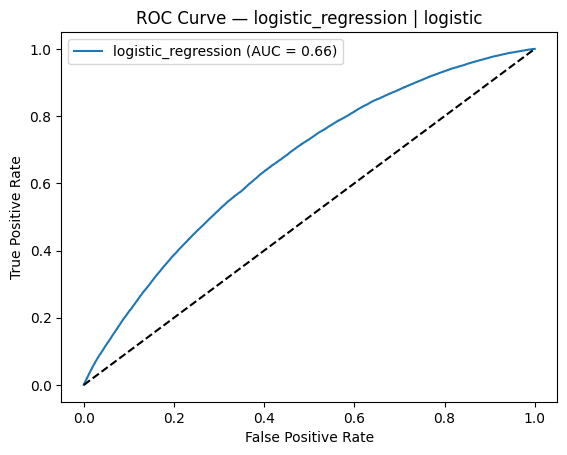

Saved: outputs/stage1_results/roc_curves/logistic_regression_logistic.png


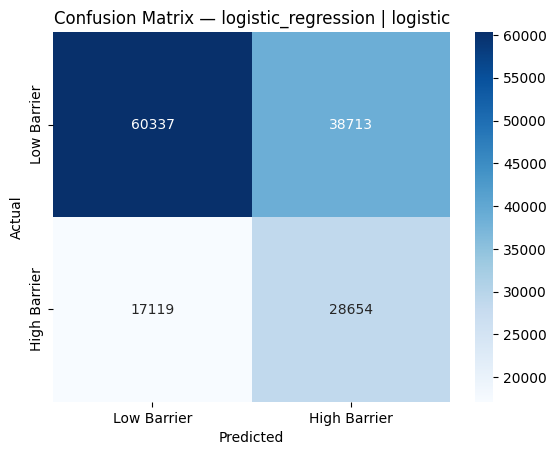

Saved: outputs/stage1_results/confusion_matrices/logistic_regression_logistic.png


In [7]:
# If running in a fresh kernel, run Cell 5 first to define model/X_test/y_test and src path.
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix

plot_roc_curve(model, X_test, y_test, "logistic_regression", "logistic")
plot_confusion_matrix(model, X_test, y_test, "logistic_regression", "logistic")

In [8]:
# If running in a fresh kernel, run Cell 5 first to define PROJECT_ROOT/X_test/y_test and src path.
from src.evaluation.visualise import plot_roc_overlay

import joblib

lr_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')
dt_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'decision_tree_logistic.pkl')
rf_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'random_forest_logistic.pkl')
xgb_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'xgboost_logistic.pkl')

plot_roc_overlay(
    {
        "Logistic Regression": lr_model,
        "Decision Tree": dt_model,
        "Random Forest": rf_model,
        "XGBoost": xgb_model,
    },
    X_test, y_test, "logistic"
)

ModuleNotFoundError: No module named 'numpy._core'

In [ ]:
out_dir = PROJECT_ROOT / 'outputs' / 'stage1_results'
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / 'logistic_results.csv'
results_df.to_csv(results_path, index=False)
print('Saved results to:', results_path)